In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zain280/concrete-data")

print("Path to dataset files:", path)

100%|██████████| 11.1k/11.1k [00:00<00:00, 8.06MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/zain280/concrete-data/versions/1


In [3]:
import pandas as pd
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zain280/concrete-data")

print("Path to dataset files:", path)

# Assuming the downloaded data is in a CSV file named 'concrete_data.csv'
data = pd.read_csv(path + '/concrete_data.csv')  # Adjust file name if needed

data.head() # Now you can call head() on the DataFrame 'data'

Path to dataset files: /root/.cache/kagglehub/datasets/zain280/concrete-data/versions/1


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import PowerTransformer

In [6]:
data.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [7]:
df = data


In [8]:
df.shape

(1030, 9)

In [9]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [10]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [11]:
#Extracting data into x and y
x = df.drop(['Strength'], axis=1)
y = df['Strength']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
#Applying Regression w/o any transformation
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2_score(y_test, y_pred)

0.627553179231485

In [14]:
#Cross validatring
lr = LinearRegression()
cv_scores = cross_val_score(lr, x, y, scoring='r2')
cv_scores.mean()

0.46099404916628606

<ipython-input-16-4bbee67d04e9>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


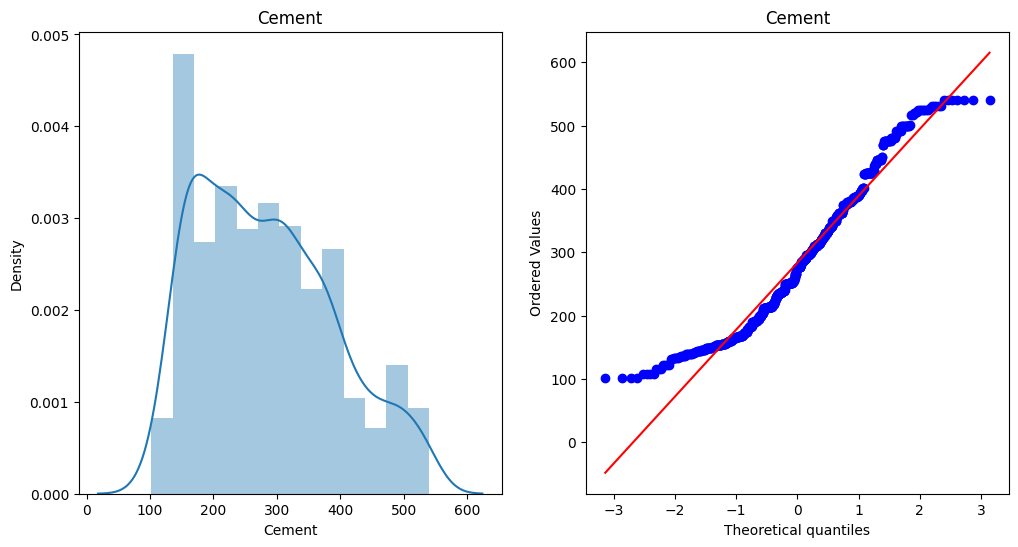

<ipython-input-16-4bbee67d04e9>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


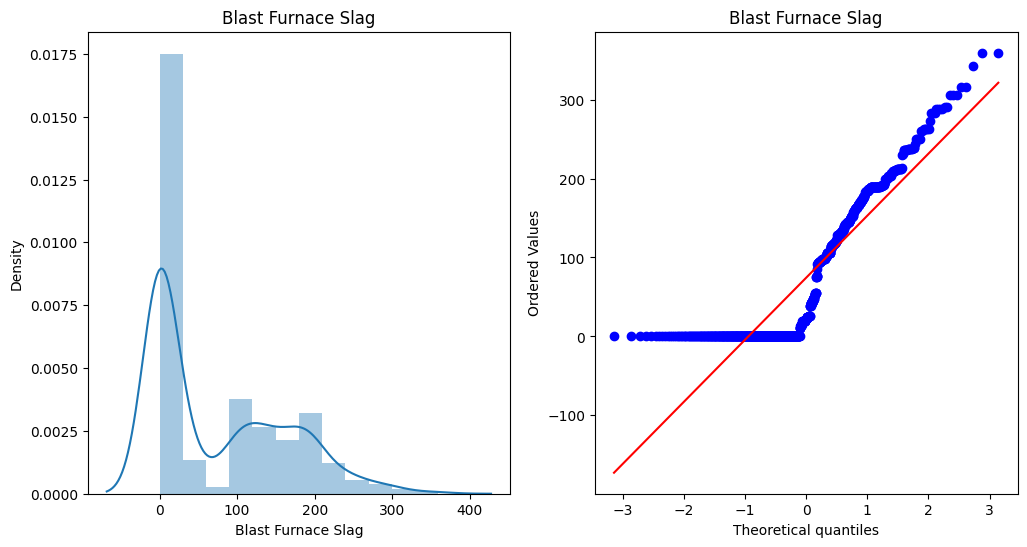

<ipython-input-16-4bbee67d04e9>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


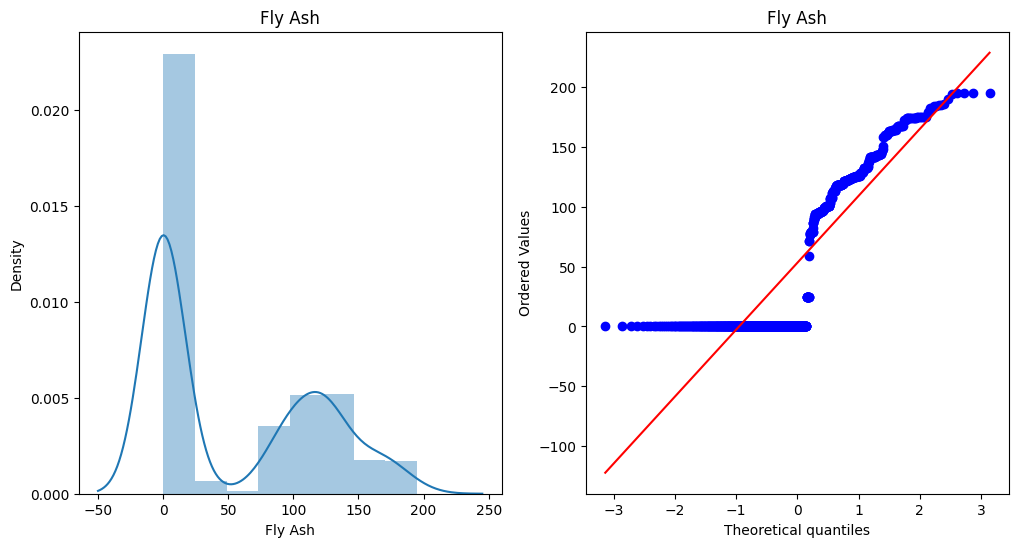

<ipython-input-16-4bbee67d04e9>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


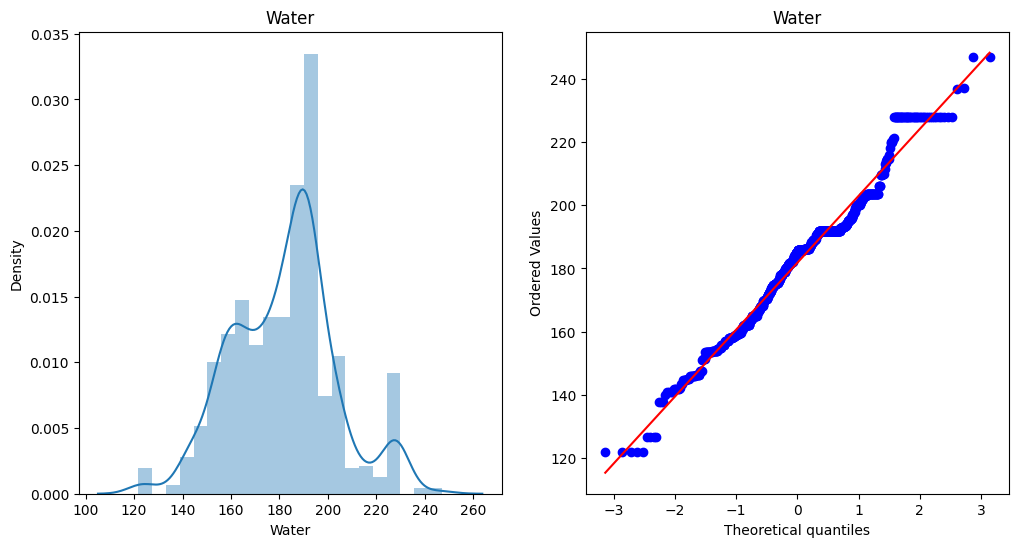

<ipython-input-16-4bbee67d04e9>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


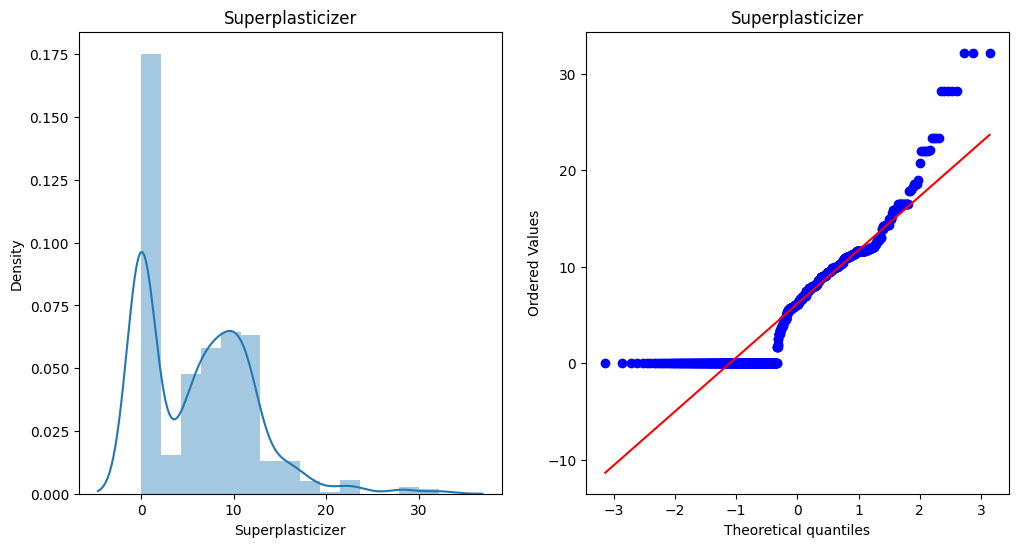

<ipython-input-16-4bbee67d04e9>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


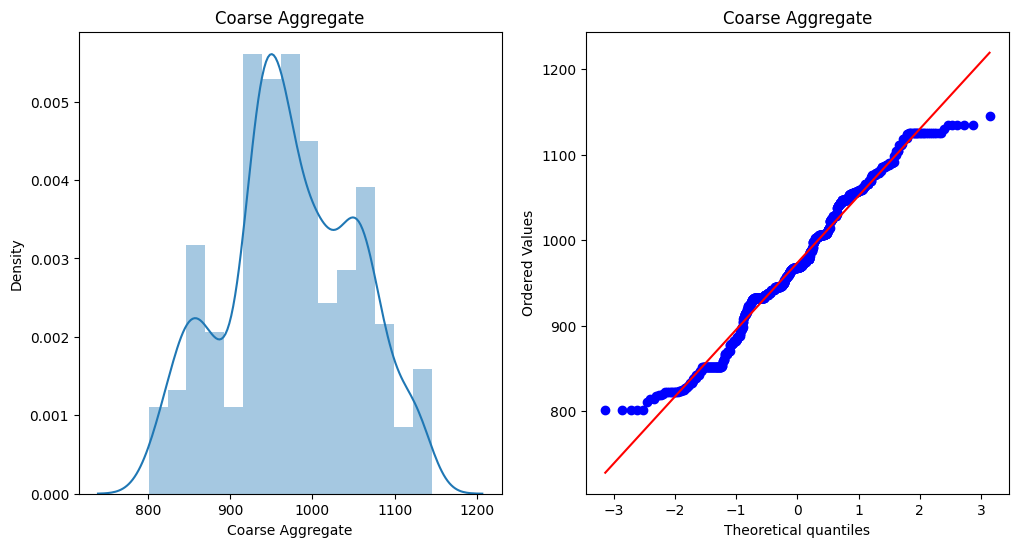

<ipython-input-16-4bbee67d04e9>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


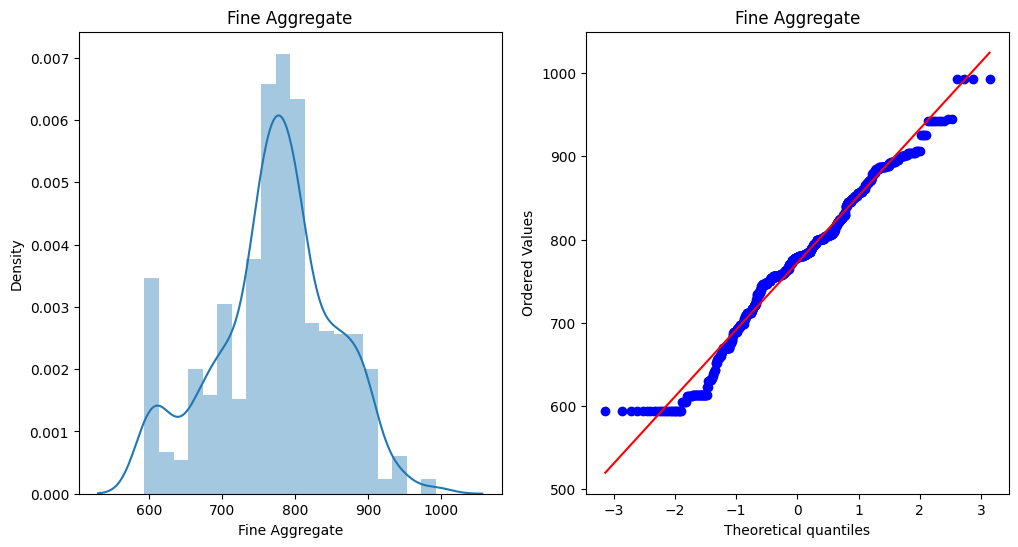

<ipython-input-16-4bbee67d04e9>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


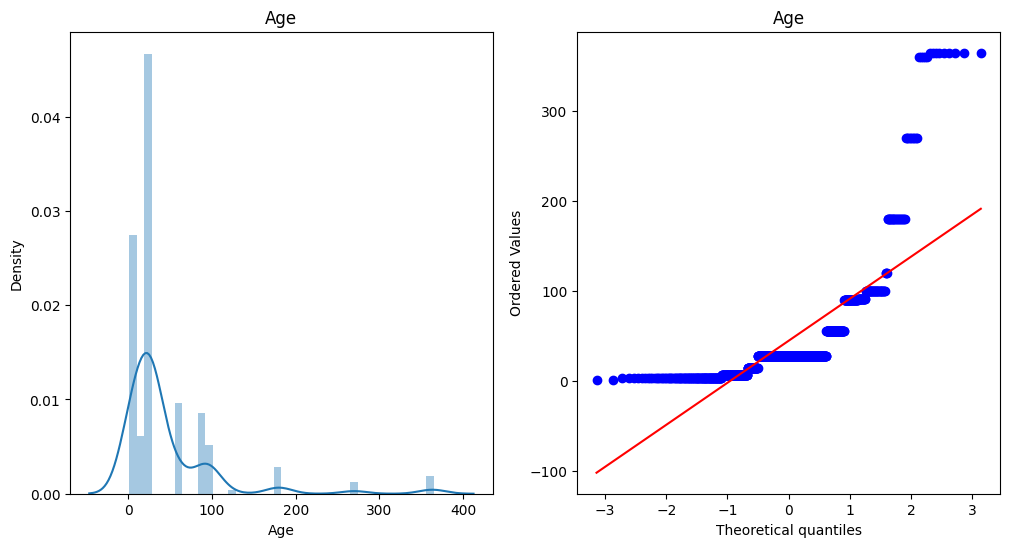

In [16]:
#PLotting all the columns w/o any transformation to analyze distribution
for col in X_train.columns:
  plt.figure(figsize=(12,6))
  plt.subplot(1,2,1)
  sns.distplot(X_train[col], kde=True)
  plt.title(col)

  plt.subplot(1,2,2)
  stats.probplot(X_train[col], dist='norm', plot=plt)
  plt.title(col)

  plt.show()


# **After Transformation**

In [17]:
pt = PowerTransformer()

X_train_transformed  = pt.fit_transform(X_train+0.000001) #Adding 0.000001 to whole data so it doesn;t encounter the problem of being equal to 0
X_test_transformed = pt.transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [20]:
#Applying Regression w/o any transformation
lr1 = LinearRegression()
lr.fit(X_train_transformed, y_train)
y_pred = lr.predict(X_test_transformed)
r2_score(y_test, y_pred)

0.8161906541864055

In [22]:
#Cross validatring
pt = PowerTransformer(method = 'box-cox')
X_transformed  = pt.fit_transform(x+0.000001) #Adding 0

lr = LinearRegression()
cv_scores = cross_val_score(lr, X_transformed, y, scoring='r2')
cv_scores.mean()

0.6662950324463968

<ipython-input-25-13f3458916cf>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col], kde=True)


TypeError: distplot() got an unexpected keyword argument 'dist'

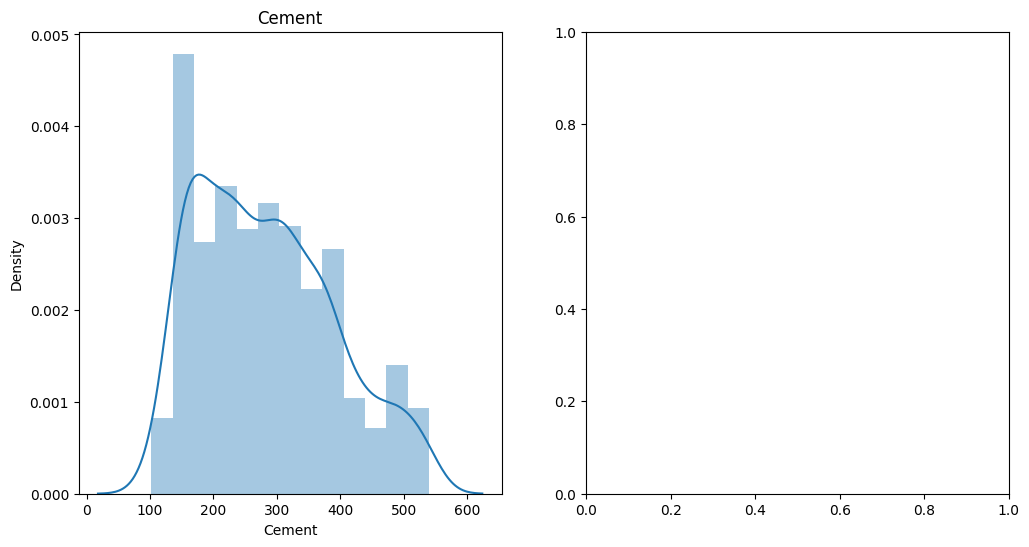

In [25]:
#PLotting all the columns w/o any transformation to analyze distribution
X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)
for col in X_train_transformed.columns:
  plt.figure(figsize=(12,6))
  plt.subplot(1,2,1)
  sns.distplot(X_train[col], kde=True)
  plt.title(col)

  plt.subplot(1,2,2)
  sns.distplot(X_train_transformed[col], dist='norm', plot=plt)
  plt.title(col)

  plt.show()


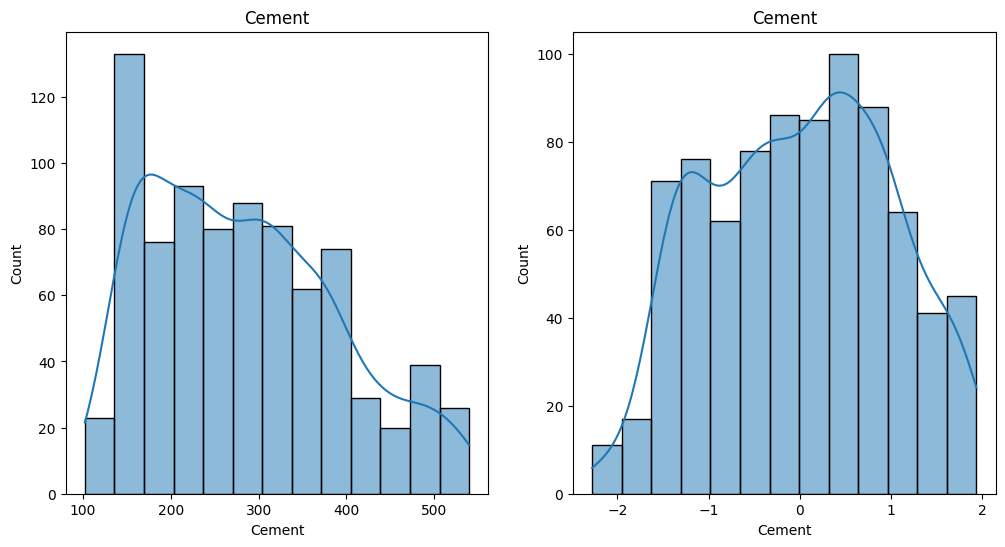

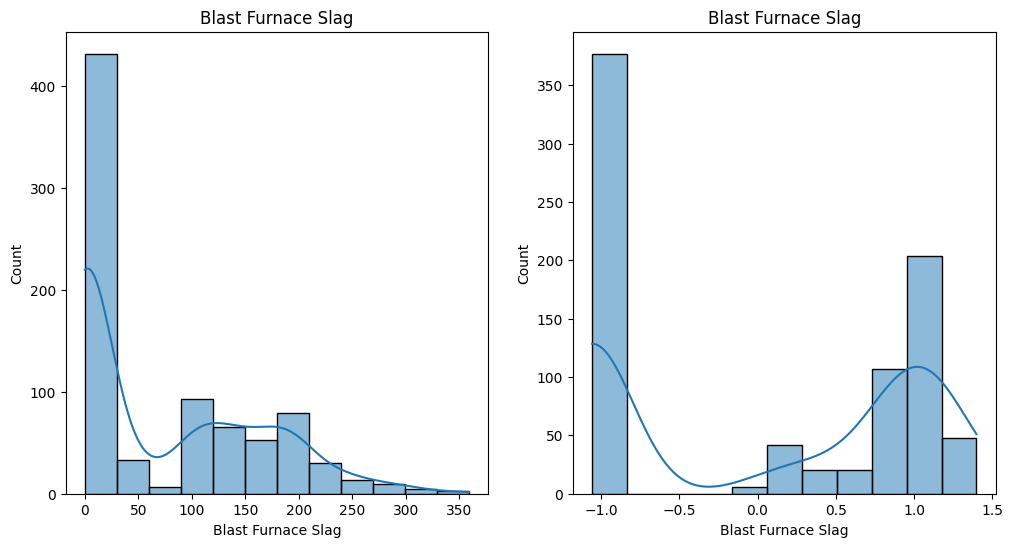

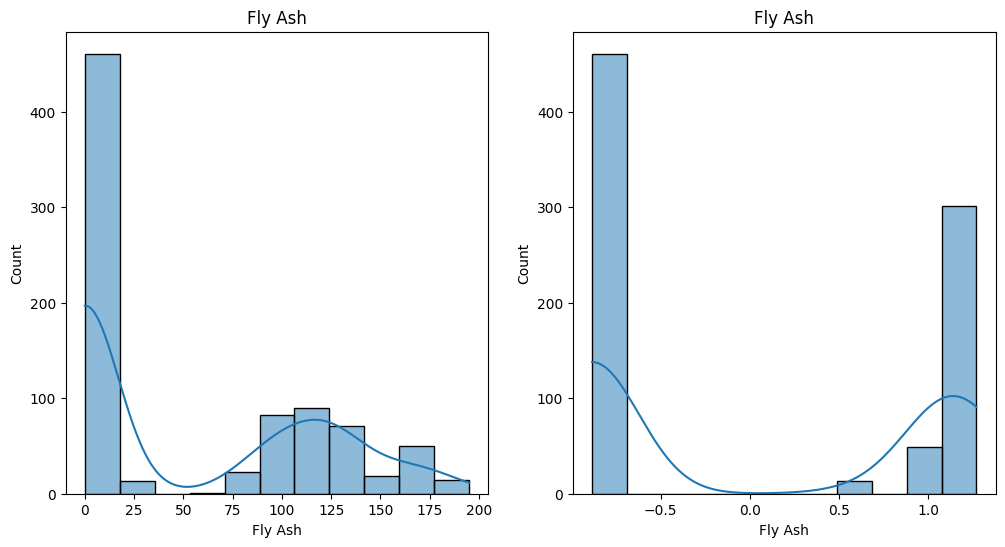

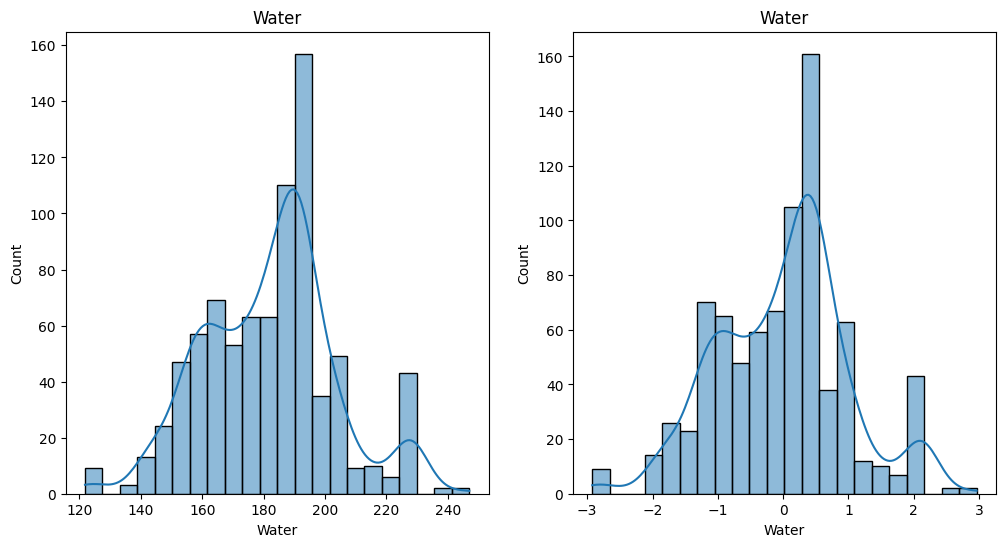

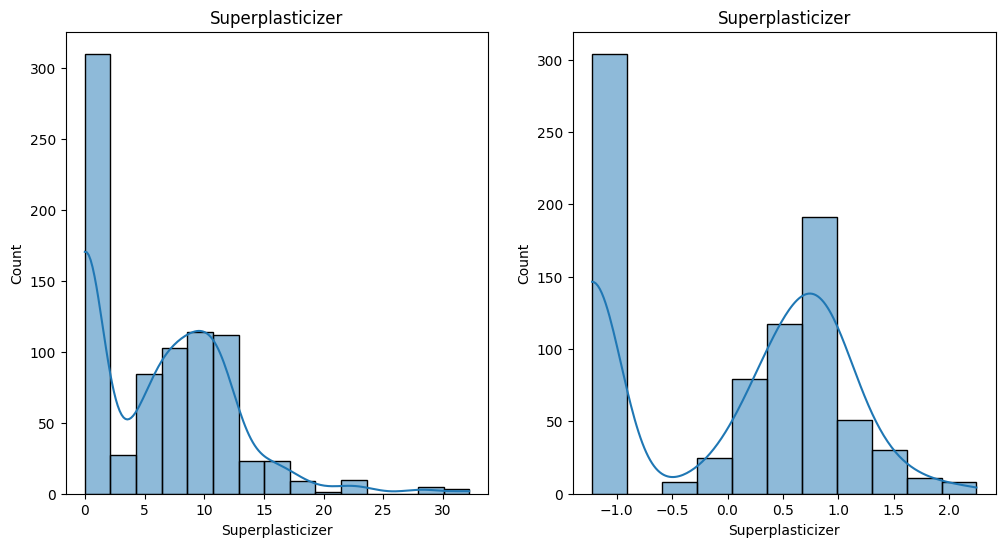

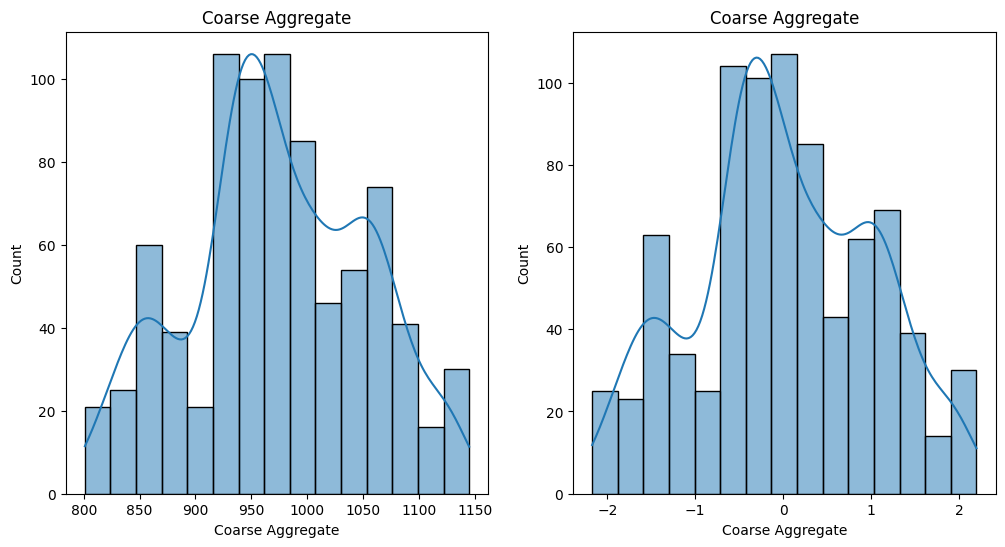

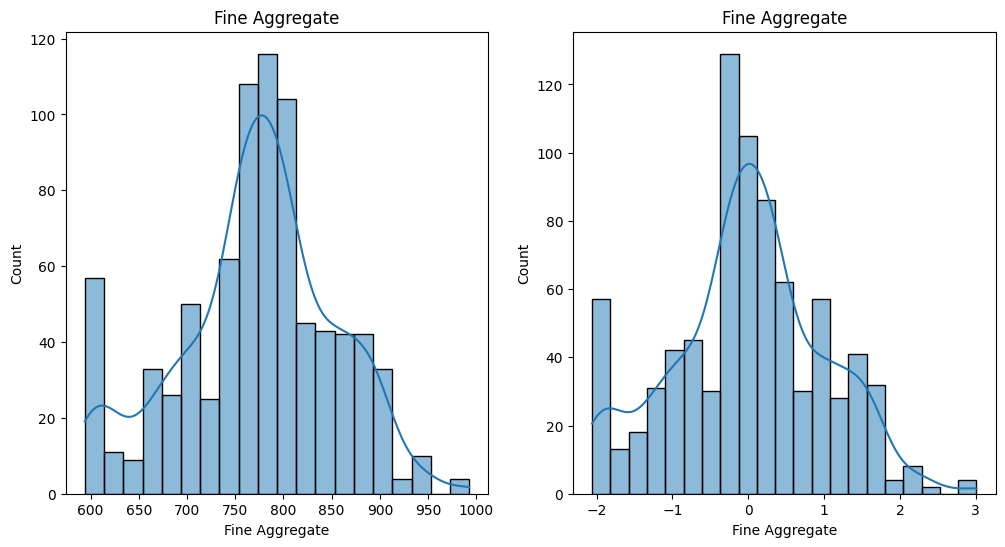

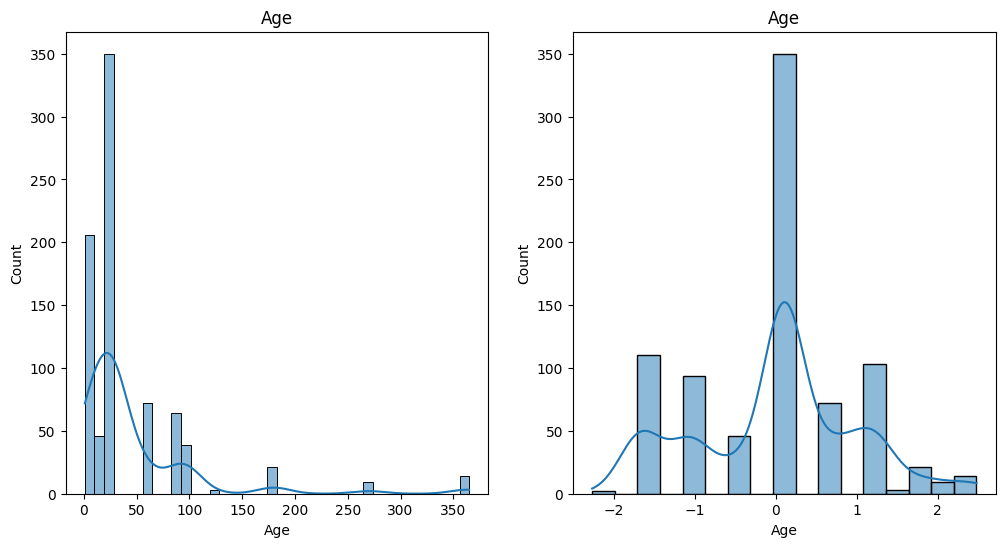

In [26]:
#PLotting all the columns w/o any transformation to analyze distribution
X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)
for col in X_train_transformed.columns:
  plt.figure(figsize=(12,6))
  plt.subplot(1,2,1)
  # Original distribution plot using sns.histplot()
  sns.histplot(X_train[col], kde=True)
  plt.title(col)

  plt.subplot(1,2,2)
  # Distribution plot after transformation using sns.histplot()
  sns.histplot(X_train_transformed[col], kde=True)
  plt.title(col)

  plt.show()

* Replicate for yeo - Johnson transformation